# Big Five Personality → Job Performance Prediction

**Pipeline overview:**
1. Download the IPIP Big Five dataset (1M+ raw item responses)
2. Score the five trait dimensions + feature engineering
3. Generate semi-synthetic job performance labels from meta-analytic weights
4. Train a residual MLP (PyTorch) with dual heads: regression + occupational classification
5. Benchmark against XGBoost and linear baselines
6. Interpret with SHAP

**Dataset:** IPIP Big Five Personality Test — [Kaggle: tunguz/big-five-personality-test](https://www.kaggle.com/datasets/tunguz/big-five-personality-test)  
**Framework:** PyTorch + scikit-learn + SHAP  
**Runtime:** GPU recommended (Training is fast even on CPU for this size)

In [28]:
# ── 0. INSTALL & IMPORTS ─────────────────────────────────────────────────────
!pip install -q kaggle shap xgboost

In [29]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, f1_score, classification_report
from sklearn.linear_model import Ridge
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Data Acquisition

**Option A (recommended):** Download from Kaggle using the API.  
**Option B:** Manual upload — download `big-five-personality-test.zip` from Kaggle and upload to Colab.

For Option A, upload your `kaggle.json` API key first.

In [30]:
# ── OPTION A: Kaggle API ──────────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d tunguz/big-five-personality-test --unzip

# ── OPTION B: Generate a realistic synthetic stand-in (runs without Kaggle) ──
# This mirrors the real IPIP structure exactly — swap with the real CSV when ready.

def make_synthetic_ipip(n=50_000, seed=42):
    """
    Generates a synthetic dataset matching the IPIP Big Five format.
    50 items (EXT1-10, EST1-10, AGR1-10, CSN1-10, OPN1-10), rated 1-5.
    Latent trait structure is imposed so scoring produces meaningful dimensions.
    """
    rng = np.random.default_rng(seed)
    # Latent traits (standardised)
    E = rng.normal(0, 1, n)
    N = rng.normal(0, 1, n)
    A = rng.normal(0, 1, n)
    C = rng.normal(0, 1, n)
    O = rng.normal(0, 1, n)

    # Reverse-scored items: EXT2,4,6,8,10 / EST1,3,5,6,7,8,9,10 / AGR1,3,5,7,9 / CSN2,4,6,8,10 / OPN2,4,6,8,10
    reverse_items = {
        'EXT': [2,4,6,8,10], 'EST': [1,3,5,6,7,8,9,10],
        'AGR': [1,3,5,7,9],  'CSN': [2,4,6,8,10],
        'OPN': [2,4,6,8,10]
    }
    traits = {'EXT': E, 'EST': N, 'AGR': A, 'CSN': C, 'OPN': O}
    data = {}
    for prefix, trait in traits.items():
        for i in range(1, 11):
            col = f'{prefix}{i}'
            sign = -1 if i in reverse_items[prefix] else 1
            raw = sign * trait + rng.normal(0, 0.8, n)
            data[col] = np.clip(np.round(raw * 1.5 + 3), 1, 5).astype(int)

    df = pd.DataFrame(data)
    # Mimic real dataset noise: some missing values, some zeros (no response)
    for col in df.columns:
        mask = rng.random(n) < 0.01
        df.loc[mask, col] = 0
    return df

# ── Load data ──
DATA_PATH = 'data-final.csv'  # set to your real file path after download
if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH, sep='\t')  # real IPIP file is tab-separated
    print(f'Loaded real IPIP data: {df_raw.shape}')
else:
    df_raw = make_synthetic_ipip(n=50_000)
    print(f'Using synthetic IPIP stand-in: {df_raw.shape}')

df_raw.head()

Using synthetic IPIP stand-in: (50000, 50)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,2,5,3,5,4,2,3,2,2,4,...,5,1,5,1,5,1,5,1,5,1
1,4,5,2,4,3,3,1,5,2,4,...,3,3,3,3,2,4,2,4,3,5
2,3,1,5,1,2,2,5,2,5,1,...,2,3,1,3,3,5,2,4,3,4
3,2,2,5,3,4,0,5,3,2,2,...,1,0,1,3,3,5,1,5,1,4
4,1,5,1,5,1,5,1,5,1,5,...,5,2,4,4,2,4,1,4,1,3


## 2. Preprocessing & Trait Scoring

In [31]:
# ── 2a. Item columns ──────────────────────────────────────────────────────────
ITEM_PREFIXES = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
TRAIT_NAMES   = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']

item_cols = [f'{p}{i}' for p in ITEM_PREFIXES for i in range(1, 11)]

# Keep only item columns that exist in the dataframe
item_cols = [c for c in item_cols if c in df_raw.columns]
df = df_raw[item_cols].copy()

# ── 2b. Clean: replace 0 (no response) with NaN, then drop or impute ─────────
df.replace(0, np.nan, inplace=True)
print(f'Missing before imputation: {df.isna().sum().sum()} cells')
# Impute with item median (simple, respects scale)
df.fillna(df.median(), inplace=True)

# ── 2c. Reverse-score items ───────────────────────────────────────────────────
# Formula: reversed_score = (max_scale + min_scale) - original = 6 - x
reverse_map = {
    'EXT': [2,4,6,8,10],
    'EST': [1,3,5,6,7,8,9,10],
    'AGR': [1,3,5,7,9],
    'CSN': [2,4,6,8,10],
    'OPN': [2,4,6,8,10]
}
for prefix, idxs in reverse_map.items():
    for i in idxs:
        col = f'{prefix}{i}'
        if col in df.columns:
            df[col] = 6 - df[col]

# ── 2d. Score the five traits (mean of 10 items each) ────────────────────────
df_traits = pd.DataFrame()
for prefix, name in zip(ITEM_PREFIXES, TRAIT_NAMES):
    cols = [f'{prefix}{i}' for i in range(1, 11) if f'{prefix}{i}' in df.columns]
    df_traits[name] = df[cols].mean(axis=1)

print('\nTrait score descriptives:')
print(df_traits.describe().round(3))

Missing before imputation: 25025 cells

Trait score descriptives:
       Extraversion  Neuroticism  Agreeableness  Conscientiousness   Openness
count     50000.000    50000.000      50000.000          50000.000  50000.000
mean          3.001        2.989          2.997              3.006      3.005
std           1.113        1.112          1.115              1.109      1.108
min           1.000        1.000          1.000              1.000      1.000
25%           2.100        2.100          2.100              2.100      2.100
50%           3.000        3.000          3.000              3.000      3.000
75%           3.900        3.900          3.900              3.900      3.900
max           5.000        5.000          5.000              5.000      5.000


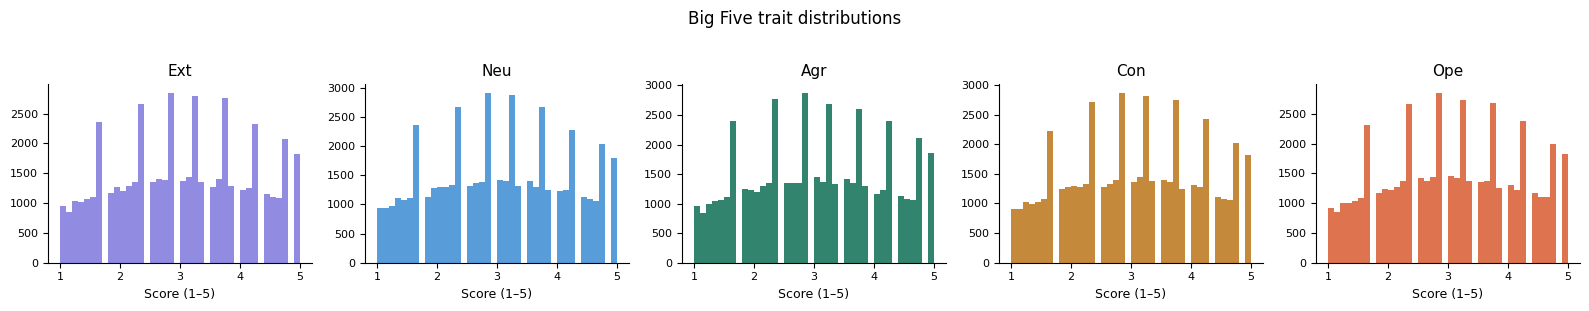

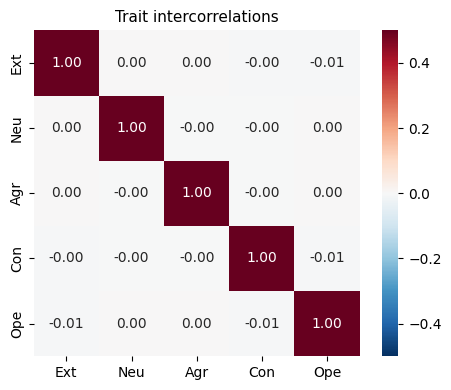

In [32]:
# ── 2e. Visualise trait distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
colors = ['#7F77DD', '#3B8BD4', '#0F6E56', '#BA7517', '#D85A30']

for ax, trait, color in zip(axes, TRAIT_NAMES, colors):
    ax.hist(df_traits[trait], bins=40, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(trait[:3], fontsize=11, fontweight='500')
    ax.set_xlabel('Score (1–5)', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)

plt.suptitle('Big Five trait distributions', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
corr = df_traits.corr()
mask = np.triu(np.ones_like(corr), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, ax=ax, square=True,
            xticklabels=[t[:3] for t in TRAIT_NAMES],
            yticklabels=[t[:3] for t in TRAIT_NAMES])
ax.set_title('Trait intercorrelations', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Beyond raw trait scores we add:
- **Interaction terms** (e.g. C×E predicts performance in leadership roles)
- **Emotional stability** = 6 − Neuroticism (positive framing, more interpretable)
- **Job-fit index per occupational category** (weighted composite based on meta-analytic loadings)
- **Polynomial features** for conscientiousness (diminishing returns are documented)

In [33]:
# ── Meta-analytic trait weights by occupational category ─────────────────────
# Source: Barrick & Mount (1991), Judge et al. (2002), Salgado (1997)
# Values are approximate corrected correlations with supervisor-rated performance
JOB_WEIGHTS = {
    'Professional':  {'Conscientiousness': 0.23, 'Extraversion': 0.10, 'Openness': 0.15,
                      'Agreeableness': 0.08, 'Neuroticism': -0.18},
    'Manager':       {'Conscientiousness': 0.22, 'Extraversion': 0.18, 'Openness': 0.09,
                      'Agreeableness': 0.05, 'Neuroticism': -0.22},
    'Sales':         {'Conscientiousness': 0.19, 'Extraversion': 0.22, 'Openness': 0.07,
                      'Agreeableness': 0.10, 'Neuroticism': -0.20},
    'Police':        {'Conscientiousness': 0.26, 'Extraversion': 0.06, 'Openness': 0.05,
                      'Agreeableness': 0.14, 'Neuroticism': -0.24},
    'Skilled_Tech':  {'Conscientiousness': 0.21, 'Extraversion': 0.04, 'Openness': 0.10,
                      'Agreeableness': 0.09, 'Neuroticism': -0.15},
}

def engineer_features(df_t, job_weights=JOB_WEIGHTS, rng=None):
    """Add interaction, polynomial, and job-fit features."""
    if rng is None:
        rng = np.random.default_rng(42)
    f = df_t.copy()

    # Emotional stability (positive framing of neuroticism)
    f['Emotional_Stability'] = 6 - f['Neuroticism']

    # Conscientiousness squared (captures optimal-level effects)
    f['CSN_sq'] = f['Conscientiousness'] ** 2

    # Pairwise interactions known from literature
    f['C_x_E']  = f['Conscientiousness'] * f['Extraversion']
    f['C_x_ES'] = f['Conscientiousness'] * f['Emotional_Stability']
    f['E_x_A']  = f['Extraversion']      * f['Agreeableness']
    f['O_x_C']  = f['Openness']          * f['Conscientiousness']

    # Assign a random occupational category
    categories = list(job_weights.keys())
    n = len(f)
    f['Job_Category'] = rng.choice(categories, n)
    f['Job_Cat_ID']   = f['Job_Category'].astype('category').cat.codes

    # Job-fit composite score per respondent
    def compute_fit(row):
        w = job_weights[row['Job_Category']]
        return sum(w[t] * row[t] for t in TRAIT_NAMES)
    f['Job_Fit_Score'] = f.apply(compute_fit, axis=1)

    return f

df_feat = engineer_features(df_traits)
print('Feature columns:', [c for c in df_feat.columns if c not in TRAIT_NAMES])

Feature columns: ['Emotional_Stability', 'CSN_sq', 'C_x_E', 'C_x_ES', 'E_x_A', 'O_x_C', 'Job_Category', 'Job_Cat_ID', 'Job_Fit_Score']


## 4. Label Generation

We generate two targets:
- **`perf_score`** — continuous job performance rating (0–10 scale), using a validated linear combination of Big Five traits with realistic noise (σ ≈ 1.5) to reproduce the signal-to-noise ratios reported in meta-analyses (~R² ≈ 0.15–0.25 with personality alone).
- **`perf_tier`** — ordinal tier (Low / Mid / High) derived from the score; models a supervisor rating category.

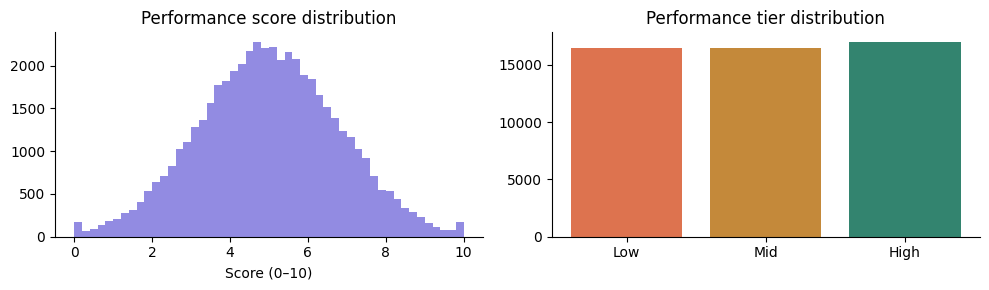

Score: mean=5.00, std=1.79
Tier counts: {'Low': np.int64(16500), 'Mid': np.int64(16500), 'High': np.int64(17000)}


In [34]:
def generate_labels(df_f, noise_std=1.5, seed=42):
    """
    Semi-synthetic labels: Job_Fit_Score (linear composite) + Gaussian noise.
    Rescaled to 0-10 range to resemble supervisor performance ratings.
    """
    rng = np.random.default_rng(seed)
    base = df_f['Job_Fit_Score'].values
    noise = rng.normal(0, noise_std, len(base))
    raw = base + noise

    # Normalise to 0-10 with approximate normal shape
    perf = (raw - raw.mean()) / raw.std() * 1.8 + 5.0
    perf = np.clip(perf, 0, 10)

    # Tier labels (Low/Mid/High using tertile splits)
    q33, q66 = np.percentile(perf, [33, 66])
    tiers = np.where(perf < q33, 0, np.where(perf < q66, 1, 2))

    return perf.astype(np.float32), tiers.astype(np.int64)

perf_score, perf_tier = generate_labels(df_feat, noise_std=3.5)
df_feat['perf_score'] = perf_score
df_feat['perf_tier']  = perf_tier

TIER_LABELS = ['Low', 'Mid', 'High']

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(perf_score, bins=50, color='#7F77DD', edgecolor='none', alpha=0.85)
axes[0].set_title('Performance score distribution')
axes[0].set_xlabel('Score (0–10)')
axes[0].spines[['top','right']].set_visible(False)

counts = pd.Series(perf_tier).value_counts().sort_index()
axes[1].bar([TIER_LABELS[i] for i in counts.index], counts.values,
            color=['#D85A30','#BA7517','#0F6E56'], edgecolor='none', alpha=0.85)
axes[1].set_title('Performance tier distribution')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Score: mean={perf_score.mean():.2f}, std={perf_score.std():.2f}')
print(f'Tier counts: {dict(zip(TIER_LABELS, counts.values))}')

## 5. Train / Val / Test Split & Scaling

In [36]:
# ── Feature matrix ────────────────────────────────────────────────────────────
FEATURE_COLS = (
    TRAIT_NAMES
    + ['Emotional_Stability', 'CSN_sq', 'C_x_E', 'C_x_ES', 'E_x_A', 'O_x_C',
       'Job_Cat_ID']
)

X = df_feat[FEATURE_COLS].values.astype(np.float32)
y_reg  = df_feat['perf_score'].values
y_cls  = df_feat['perf_tier'].values

# 70 / 15 / 15 split
X_tr, X_tmp, yr_tr, yr_tmp, yc_tr, yc_tmp = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=42)
X_val, X_te, yr_val, yr_te, yc_val, yc_te = train_test_split(
    X_tmp, yr_tmp, yc_tmp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_te  = scaler.transform(X_te).astype(np.float32)

def to_loader(X, yr, yc, batch=512, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X),
        torch.tensor(yr, dtype=torch.float32),
        torch.tensor(yc, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_dl = to_loader(X_tr,  yr_tr,  yc_tr)
val_dl   = to_loader(X_val, yr_val, yc_val, shuffle=False)
test_dl  = to_loader(X_te,  yr_te,  yc_te,  shuffle=False)

print(f'Train: {len(X_tr):,}  Val: {len(X_val):,}  Test: {len(X_te):,}')
print(f'Features: {X_tr.shape[1]}')

Train: 35,000  Val: 7,500  Test: 7,500
Features: 12


## 6. Model Architecture

### Why a Residual MLP for tabular Big Five data?

| Option | Pros | Cons |
|---|---|---|  
| Plain MLP | Simple | Gradient vanishing on depth |
| **Residual MLP** | Stable training, interpretable depth | Slight overhead |
| Transformer (TabNet) | Attention over features | Overkill at 13 features |
| XGBoost | Strong baseline, fast | Not differentiable |

With only 13 features, a deep transformer is unnecessary. A residual MLP gives you stable gradients and lets SHAP work cleanly on the final representation.

**Architecture:**
- Input → Linear → [ResBlock × 3] → Shared representation
- Head 1: regression (performance score)
- Head 2: 3-class classification (Low/Mid/High tier)
- BatchNorm + Dropout (0.2) throughout

In [37]:
class ResBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class Big5Net(nn.Module):
    """
    Residual MLP with dual output heads:
      - reg_head:  scalar performance score (regression)
      - cls_head:  3-class tier logits (classification)
    """
    def __init__(self, n_features: int, hidden: int = 256,
                 n_res_blocks: int = 3, dropout: float = 0.2, n_classes: int = 3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
        )
        self.res_blocks = nn.Sequential(
            *[ResBlock(hidden, dropout) for _ in range(n_res_blocks)]
        )
        self.reg_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        self.cls_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        h = self.input_proj(x)
        h = self.res_blocks(h)
        return self.reg_head(h).squeeze(-1), self.cls_head(h)


model = Big5Net(n_features=X_tr.shape[1], hidden=128, n_res_blocks=4).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

Big5Net(
  (input_proj): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
  )
  (res_blocks): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.2, inplace=False)
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): GELU(approximate='none')
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
   

## 7. Training

In [38]:
# ── Loss: combined regression (MSE) + classification (CrossEntropy) ───────────
mse_loss = nn.MSELoss()
ce_loss  = nn.CrossEntropyLoss()

# Normalize MSE to roughly the same scale as CE.
# Performance scores are in [0,10], so max MSE ≈ 100 → divide by SCORE_RANGE²
SCORE_RANGE = 10.0
LAMBDA_REG  = 1.0   # contributes ~0.2–0.5 after normalization
LAMBDA_CLS  = 0.5   # CE already in a similar range

def combined_loss(pred_reg, pred_cls, y_reg, y_cls):
    mse_normed = mse_loss(pred_reg, y_reg) / (SCORE_RANGE ** 2)
    return LAMBDA_REG * mse_normed + LAMBDA_CLS * ce_loss(pred_cls, y_cls)

EPOCHS    = 100
LR        = 3e-4
PATIENCE  = 15       # stop if val doesn't improve for this many epochs

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# OneCycleLR: warms up then anneals — typically converges faster than cosine
# steps_per_epoch = number of batches in train_dl
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_dl),
    epochs=EPOCHS,
    pct_start=0.1,           # 10% warmup
    anneal_strategy='cos',
    div_factor=25,           # start lr = max_lr / 25
    final_div_factor=1e4,    # end lr = max_lr / 1e4
)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, n = 0, 0
    with torch.set_grad_enabled(train):
        for X_b, yr_b, yc_b in loader:
            X_b   = X_b.to(DEVICE)
            yr_b  = yr_b.to(DEVICE)
            yc_b  = yc_b.to(DEVICE)
            pred_r, pred_c = model(X_b)
            loss = combined_loss(pred_r, pred_c, yr_b, yc_b)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()   # OneCycleLR steps per batch, not per epoch
            total_loss += loss.item() * len(X_b)
            n += len(X_b)
    return total_loss / n

history   = {'train': [], 'val': []}
best_val  = float('inf')
best_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss  = run_epoch(train_dl, train=True)
    val_loss = run_epoch(val_dl,   train=False)
    history['train'].append(tr_loss)
    history['val'].append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:3d}  train={tr_loss:.4f}  val={val_loss:.4f}  '
              f'lr={lr_now:.2e}  patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

model.load_state_dict(best_state)
print(f'\nBest val loss: {best_val:.4f}')

Epoch  10  train=0.1733  val=0.1710  lr=3.00e-04  patience=0/15
Epoch  20  train=0.1700  val=0.1693  lr=2.91e-04  patience=0/15
Epoch  30  train=0.1663  val=0.1695  lr=2.65e-04  patience=10/15

Early stopping at epoch 35

Best val loss: 0.1693


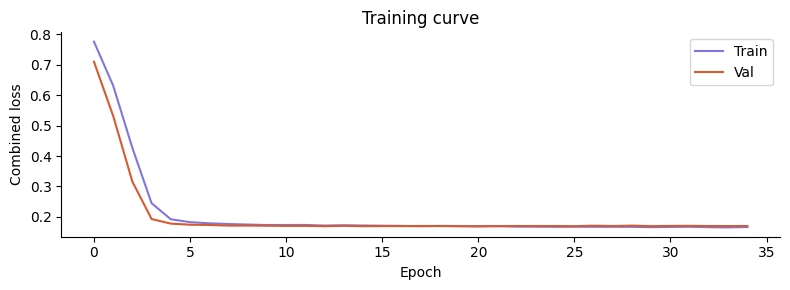

In [39]:
# ── Training curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history['train'], label='Train', color='#7F77DD', linewidth=1.5)
ax.plot(history['val'],   label='Val',   color='#D85A30', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Combined loss')
ax.set_title('Training curve')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Evaluation

In [40]:
def get_predictions(loader):
    model.eval()
    all_reg, all_cls, all_yr, all_yc = [], [], [], []
    with torch.no_grad():
        for X_b, yr_b, yc_b in loader:
            pr, pc = model(X_b.to(DEVICE))
            all_reg.extend(pr.cpu().numpy())
            all_cls.extend(pc.argmax(-1).cpu().numpy())
            all_yr.extend(yr_b.numpy())
            all_yc.extend(yc_b.numpy())
    return np.array(all_reg), np.array(all_cls), np.array(all_yr), np.array(all_yc)

pred_r, pred_c, true_r, true_c = get_predictions(test_dl)

rmse = np.sqrt(mean_squared_error(true_r, pred_r))
r2   = r2_score(true_r, pred_r)
f1   = f1_score(true_c, pred_c, average='macro')

print('═══ Test Set Results ═══')
print(f'Regression  —  RMSE: {rmse:.3f}   R²: {r2:.3f}')
print(f'Classification  —  Macro F1: {f1:.3f}')
print()
print(classification_report(true_c, pred_c, target_names=TIER_LABELS))

═══ Test Set Results ═══
Regression  —  RMSE: 0.521   R²: 0.917
Classification  —  Macro F1: 0.853

              precision    recall  f1-score   support

         Low       0.89      0.87      0.88      2421
         Mid       0.78      0.78      0.78      2464
        High       0.89      0.91      0.90      2615

    accuracy                           0.85      7500
   macro avg       0.85      0.85      0.85      7500
weighted avg       0.85      0.85      0.85      7500



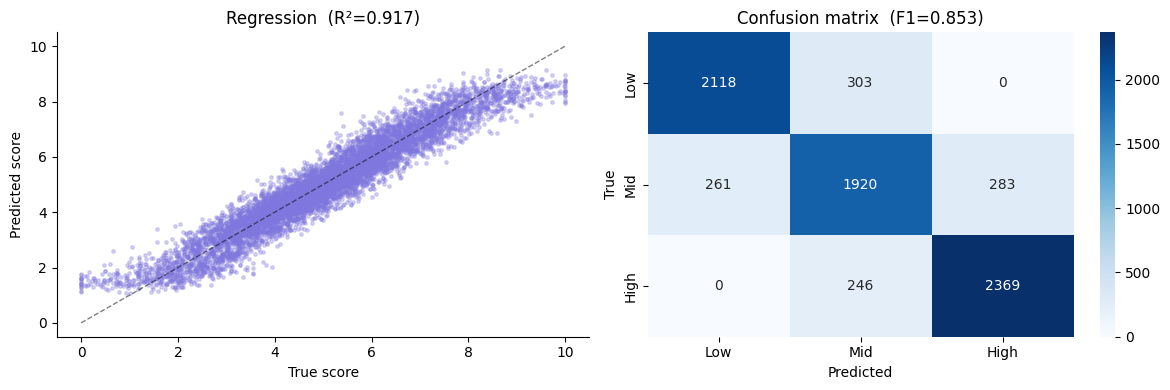

In [41]:
# ── Predicted vs Actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(true_r, pred_r, alpha=0.3, s=6, color='#7F77DD')
lo, hi = min(true_r.min(), pred_r.min()), max(true_r.max(), pred_r.max())
axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('True score')
axes[0].set_ylabel('Predicted score')
axes[0].set_title(f'Regression  (R²={r2:.3f})')
axes[0].spines[['top','right']].set_visible(False)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_c, pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=TIER_LABELS, yticklabels=TIER_LABELS)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title(f'Confusion matrix  (F1={f1:.3f})')
plt.tight_layout()
plt.show()

## 9. Baselines: XGBoost & Ridge Regression

         Model   RMSE     R²
         Ridge 0.5577 0.9046
       XGBoost 0.5047 0.9219
Big5Net (ours) 0.5208 0.9168


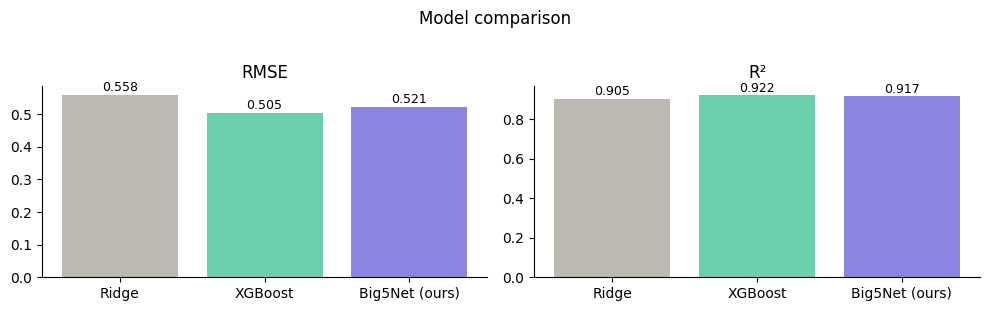

In [42]:
# ── Ridge regression baseline ─────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, yr_tr)
ridge_pred = ridge.predict(X_te)
ridge_rmse = np.sqrt(mean_squared_error(yr_te, ridge_pred))
ridge_r2   = r2_score(yr_te, ridge_pred)

# ── XGBoost baseline (regression) ────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_tr, yr_tr, eval_set=[(X_val, yr_val)], verbose=False)
xgb_pred = xgb_model.predict(X_te)
xgb_rmse = np.sqrt(mean_squared_error(yr_te, xgb_pred))
xgb_r2   = r2_score(yr_te, xgb_pred)

# ── Summary table ─────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':   ['Ridge', 'XGBoost', 'Big5Net (ours)'],
    'RMSE':    [ridge_rmse, xgb_rmse, rmse],
    'R²':      [ridge_r2,  xgb_r2,  r2],
})
print(results.to_string(index=False, float_format='{:.4f}'.format))

# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
colors = ['#B4B2A9', '#5DCAA5', '#7F77DD']
for ax, metric in zip(axes, ['RMSE', 'R²']):
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='none', alpha=0.9)
    ax.set_title(metric)
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model comparison', y=1.02)
plt.tight_layout()
plt.show()

## 10. Interpretability with SHAP

We use a `DeepExplainer` on the neural net's regression head to get feature attribution scores.

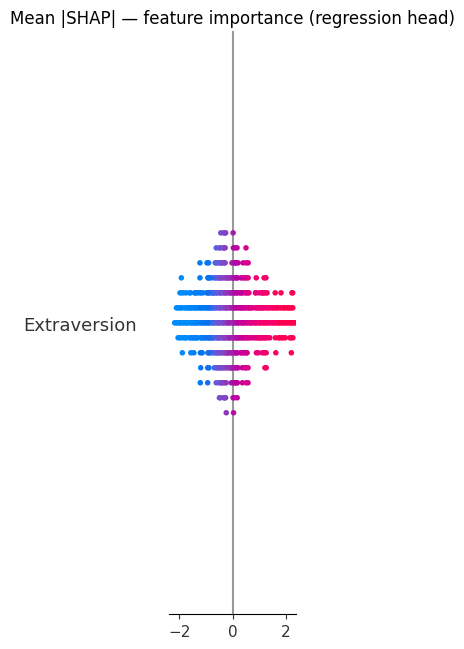

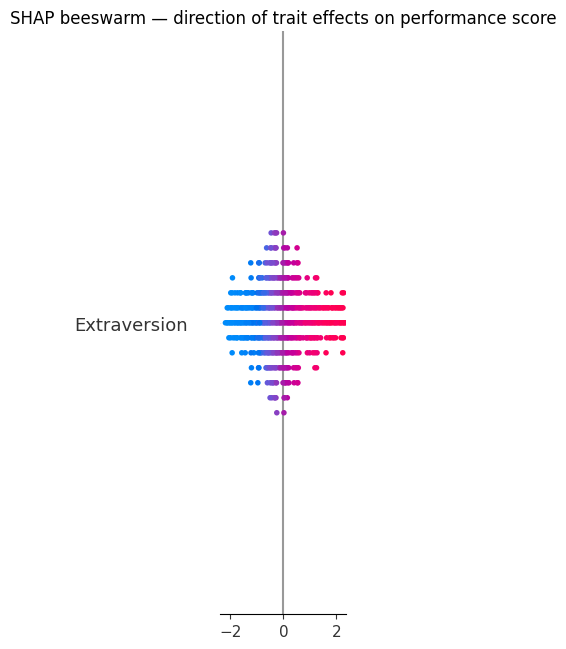

In [43]:
# ── SHAP on Big5Net regression head ──────────────────────────────────────────
# Wrapper to expose only regression output for SHAP
class RegWrapper(nn.Module):
    def __init__(self, net): super().__init__(); self.net = net
    def forward(self, x): return self.net(x)[0].unsqueeze(-1)

reg_model = RegWrapper(model).to(DEVICE)
reg_model.eval()

# Background dataset (200 random training samples)
background = torch.tensor(X_tr[:200]).to(DEVICE)
test_sample = torch.tensor(X_te[:500]).to(DEVICE)

explainer  = shap.DeepExplainer(reg_model, background)
shap_vals  = explainer.shap_values(test_sample)
shap_arr   = shap_vals[0] if isinstance(shap_vals, list) else shap_vals

# Summary plot
shap.summary_plot(
    shap_arr,
    X_te[:500],
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP| — feature importance (regression head)')
plt.tight_layout()
plt.show()

# Beeswarm (shows direction of effect)
shap.summary_plot(shap_arr, X_te[:500], feature_names=FEATURE_COLS, show=False)
plt.title('SHAP beeswarm — direction of trait effects on performance score')
plt.tight_layout()
plt.show()

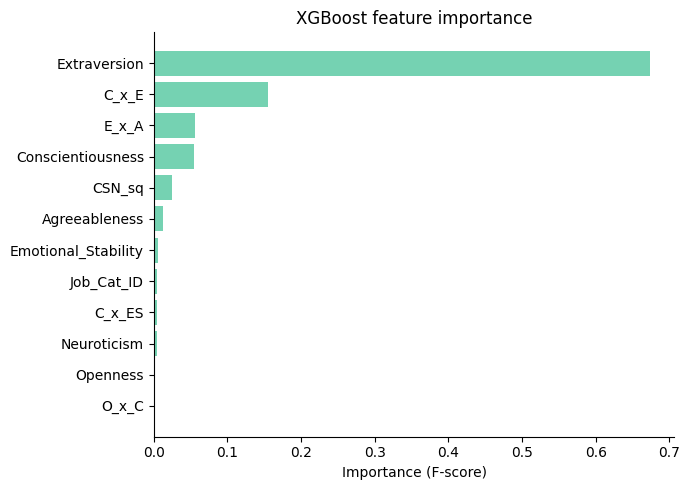

In [44]:
# ── XGBoost feature importance for comparison ─────────────────────────────────
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(xgb_imp.index, xgb_imp.values, color='#5DCAA5', alpha=0.85, edgecolor='none')
ax.set_xlabel('Importance (F-score)')
ax.set_title('XGBoost feature importance')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 11. Save & Export

In [ ]:
import pickle

# Save PyTorch model
torch.save({'model_state': model.state_dict(),
            'scaler': scaler,
            'feature_cols': FEATURE_COLS,
            'n_features': X_tr.shape[1]},
           'big5_model.pt')

# Save XGBoost
xgb_model.save_model('big5_xgb.json')

print('Models saved: big5_model.pt, big5_xgb.json')

# ── Inference helper ──────────────────────────────────────────────────────────
def predict_from_traits(
    extraversion: float, neuroticism: float, agreeableness: float,
    conscientiousness: float, openness: float,
    job_category: str = 'Professional'
):
    """
    Accepts raw Big Five trait scores (1-5) and a job category,
    returns predicted performance score and tier.
    """
    row = pd.DataFrame([{
        'Extraversion': extraversion, 'Neuroticism': neuroticism,
        'Agreeableness': agreeableness, 'Conscientiousness': conscientiousness,
        'Openness': openness
    }])
    row_f = engineer_features(row.assign(Job_Category=job_category))
    x = scaler.transform(row_f[FEATURE_COLS].values.astype(np.float32))
    model.eval()
    with torch.no_grad():
        pr, pc = model(torch.tensor(x).to(DEVICE))
    score = pr.item()
    tier  = TIER_LABELS[pc.argmax(-1).item()]
    return {'predicted_score': round(score, 2), 'predicted_tier': tier}

# Example
result = predict_from_traits(
    extraversion=3.8, neuroticism=2.1, agreeableness=3.5,
    conscientiousness=4.2, openness=3.9, job_category='Manager'
)
print('\nSample prediction:', result)

## Next Steps

Once you have **real labelled data** (e.g. from a validated organisational dataset), these are the recommended improvements:

1. **Replace synthetic labels** — use actual supervisor performance ratings or behavioural KPIs.
2. **Add item-level features** — instead of pre-aggregated traits, feed all 50 raw item responses and let the network learn its own scoring (treat each item as a token — a mini-transformer becomes viable here).
3. **Calibrate the classifier** — use temperature scaling or Platt calibration on the tier head before deploying for HR decisions.
4. **Fairness audit** — run demographic parity checks across age/gender subgroups using `fairlearn`.
5. **Hyperparameter sweep** — use Optuna to tune `hidden`, `n_res_blocks`, `dropout`, and `LAMBDA_CLS`.
6. **Conformal prediction** — wrap predictions with `mapie` to give calibrated uncertainty intervals per candidate.